# Прогнозирование оттока клиентов в сети отелей

## Загрузка библиотек и файлов

In [1]:
!pip install scikit-learn==1.1.3

     |████████████████████████████████| 30.8 MB 23.8 MB/s eta 0:00:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 0.24.1
    Uninstalling scikit-learn-0.24.1:
      Successfully uninstalled scikit-learn-0.24.1


In [2]:
pip install phik

     |████████████████████████████████| 679 kB 1.8 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [187]:
import warnings
warnings.filterwarnings("ignore")

In [301]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from phik import phik_matrix

from sklearn.compose import ColumnTransformer

from sklearn.model_selection import GridSearchCV

import phik
from phik.report import plot_correlation_matrix
from phik import report


from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    roc_curve,
    recall_score
)

from sklearn.utils import shuffle

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

Откроем два датасета с обучающей выборкой и тестовой

In [189]:
data_train = pd.read_csv('/datasets/hotel_train.csv')
data_test = pd.read_csv('/datasets/hotel_test.csv')

## Предобработка и исследовательский анализ данных

### Проверка общей информации в датасетах

In [190]:
data_train.head()

,id,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,days_in_waiting_list,customer_type,required_car_parking_spaces,total_of_special_requests,total_nights
0,0,0,7.0,2015,July,27,1,0,1,1.0,0.0,0.0,BB,GBR,Direct,0,0,0,A,0,0,Transient,0,0,1
1,1,0,14.0,2015,July,27,1,0,2,2.0,0.0,0.0,BB,GBR,TA/TO,0,0,0,A,0,0,Transient,0,1,2
2,2,0,0.0,2015,July,27,1,0,2,2.0,0.0,0.0,BB,PRT,Direct,0,0,0,C,0,0,Transient,0,0,2
3,3,0,9.0,2015,July,27,1,0,2,2.0,0.0,0.0,FB,PRT,Direct,0,0,0,C,0,0,Transient,0,1,2
4,4,1,85.0,2015,July,27,1,0,3,2.0,0.0,0.0,BB,PRT,TA/TO,0,0,0,A,0,0,Transient,0,1,3


In [191]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65229 entries, 0 to 65228
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              65229 non-null  int64  
 1   is_canceled                     65229 non-null  int64  
 2   lead_time                       65229 non-null  float64
 3   arrival_date_year               65229 non-null  int64  
 4   arrival_date_month              65229 non-null  object 
 5   arrival_date_week_number        65229 non-null  int64  
 6   arrival_date_day_of_month       65229 non-null  int64  
 7   stays_in_weekend_nights         65229 non-null  int64  
 8   stays_in_week_nights            65229 non-null  int64  
 9   adults                          65229 non-null  float64
 10  children                        65229 non-null  float64
 11  babies                          65229 non-null  float64
 12  meal                            

In [192]:
data_test.head()

,id,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,days_in_waiting_list,customer_type,required_car_parking_spaces,total_of_special_requests,total_nights
0,6086,1,74.0,2017,January,1,1,1,0,2.0,0.0,0.0,BB,PRT,TA/TO,0,0,0,A,0,0,Transient,0,0,1
1,6087,1,62.0,2017,January,1,1,2,2,2.0,0.0,0.0,BB,AUT,TA/TO,0,0,0,A,0,0,Transient,0,1,4
2,6088,1,62.0,2017,January,1,1,2,2,2.0,0.0,0.0,BB,AUT,TA/TO,0,0,0,A,0,0,Transient,0,1,4
3,6089,1,71.0,2017,January,1,1,2,2,1.0,0.0,0.0,BB,PRT,TA/TO,0,0,0,A,0,0,Transient,0,1,4
4,6090,1,172.0,2017,January,1,1,2,5,2.0,0.0,0.0,BB,BEL,TA/TO,0,0,0,A,0,0,Transient,0,0,7


In [193]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32412 entries, 0 to 32411
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              32412 non-null  int64  
 1   is_canceled                     32412 non-null  int64  
 2   lead_time                       32412 non-null  float64
 3   arrival_date_year               32412 non-null  int64  
 4   arrival_date_month              32412 non-null  object 
 5   arrival_date_week_number        32412 non-null  int64  
 6   arrival_date_day_of_month       32412 non-null  int64  
 7   stays_in_weekend_nights         32412 non-null  int64  
 8   stays_in_week_nights            32412 non-null  int64  
 9   adults                          32412 non-null  float64
 10  children                        32412 non-null  float64
 11  babies                          32412 non-null  float64
 12  meal                            

In [194]:
# Проверим, одинаковые ли типы данных в датасетах
data_train.dtypes == data_test.dtypes

id                                True
is_canceled                       True
lead_time                         True
arrival_date_year                 True
arrival_date_month                True
arrival_date_week_number          True
arrival_date_day_of_month         True
stays_in_weekend_nights           True
stays_in_week_nights              True
adults                            True
children                          True
babies                            True
meal                              True
country                           True
distribution_channel              True
is_repeated_guest                 True
previous_cancellations            True
previous_bookings_not_canceled    True
reserved_room_type                True
booking_changes                   True
days_in_waiting_list              True
customer_type                     True
required_car_parking_spaces       True
total_of_special_requests         True
total_nights                      True
dtype: bool

Во обоих датасетах одинаковый набор данных (одинаковые колонки, одинаковый тип данных). Пропусков нет.

**Количественные данные:**

id — номер записи;  
arrival_date_year — год заезда;   
arrival_date_week_number — неделя заезда;  
arrival_date_day_of_month — день заезда;   
adults — количество взрослых постояльцев;    
babies — количество младенцев;  
booking_changes — количество изменений параметров заказа;  
children — количество детей от 3 до 14 лет;   
days_in_waiting_list — сколько дней заказ ожидал подтверждения;  
lead_time — количество дней между датой бронирования и датой прибытия;  
previous_bookings_not_canceled — количество подтверждённых заказов у клиента;  
previous_cancellations — количество отменённых заказов у клиента;  
stays_in_weekend_nights — количество ночей в выходные дни;  
stays_in_week_nights — количество ночей в будние дни;  
total_nights — общее количество ночей;  
total_of_special_requests — количество специальных отметок.  
is_canceled — отмена заказа;  
is_repeated_guest — признак того, что гость бронирует номер второй раз   
required_car_parking_spaces — необходимость места для автомобиля  

**Категориальные данные:**
 
country — гражданство постояльца;  
arrival_date_month — месяц заезда; 
customer_type — тип заказчика:  
Contract — договор с юридическим лицом;    
Group — групповой заезд;    
Transient — не связано с договором или групповым заездом;    
Transient-party — не связано с договором или групповым заездом, но связано с бронированием типа Transient.    
  
distribution_channel — канал дистрибуции заказа;  
meal — опции заказа:  
  SC — нет дополнительных опций;     
  BB — включён завтрак;    
  HB — включён завтрак и обед;  
  FB — включён завтрак, обед и ужин.  

reserved_room_type — тип забронированной комнаты;  

Изменим тип данных для удобства с float на int в колонках с целочисленными данными: 'children','adults','babies', 'lead_time'

In [195]:
columns = ['children','adults','babies', 'lead_time']

for i in columns:
    data_train[i] = data_train[i].astype(int)
    data_test[i] = data_test[i].astype(int)

In [196]:
# Проверим внесенные изменения
data_train.dtypes

id                                 int64
is_canceled                        int64
lead_time                          int64
arrival_date_year                  int64
arrival_date_month                object
arrival_date_week_number           int64
arrival_date_day_of_month          int64
stays_in_weekend_nights            int64
stays_in_week_nights               int64
adults                             int64
children                           int64
babies                             int64
meal                              object
country                           object
distribution_channel              object
is_repeated_guest                  int64
previous_cancellations             int64
previous_bookings_not_canceled     int64
reserved_room_type                object
booking_changes                    int64
days_in_waiting_list               int64
customer_type                     object
required_car_parking_spaces        int64
total_of_special_requests          int64
total_nights    

In [197]:
# Проверим внесенные изменения
data_test.dtypes

id                                 int64
is_canceled                        int64
lead_time                          int64
arrival_date_year                  int64
arrival_date_month                object
arrival_date_week_number           int64
arrival_date_day_of_month          int64
stays_in_weekend_nights            int64
stays_in_week_nights               int64
adults                             int64
children                           int64
babies                             int64
meal                              object
country                           object
distribution_channel              object
is_repeated_guest                  int64
previous_cancellations             int64
previous_bookings_not_canceled     int64
reserved_room_type                object
booking_changes                    int64
days_in_waiting_list               int64
customer_type                     object
required_car_parking_spaces        int64
total_of_special_requests          int64
total_nights    

Проверим данные на явные дубликаты

In [198]:
data_train.duplicated().sum()

0

In [199]:
data_test.duplicated().sum()

0

Построим общую гистограмму для всех числовых столбцов таблицы. Проверим распределение количественных признаков

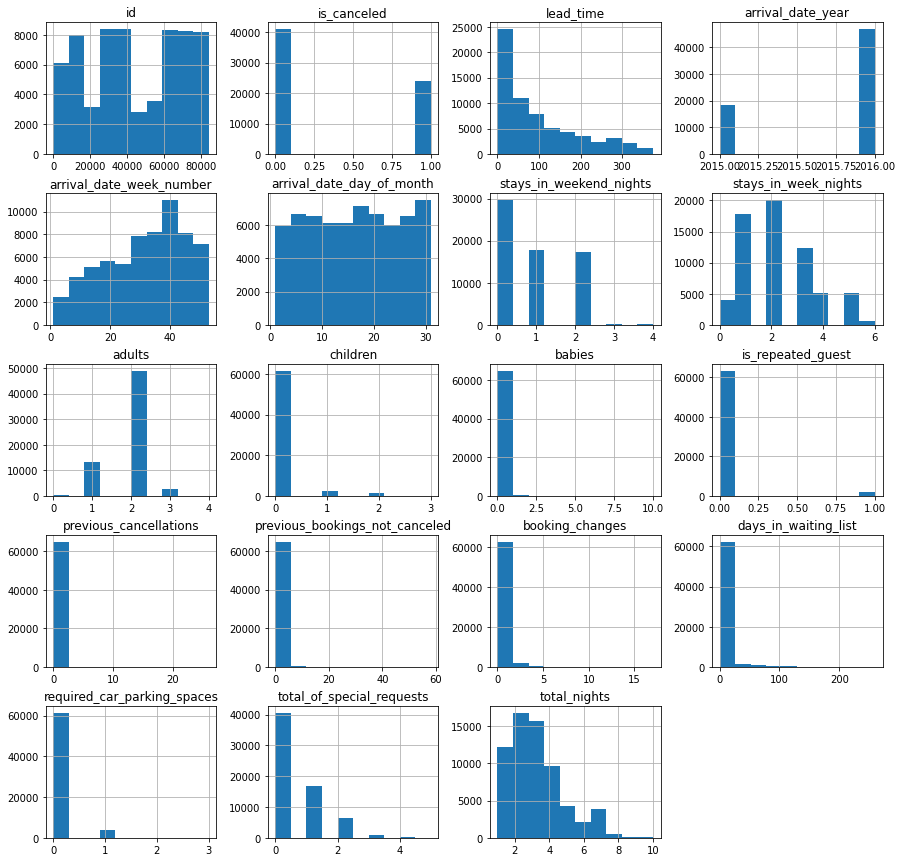

In [200]:
# Гистограмма для датасета с обучающей выборкой
data_train.hist(figsize=(15, 15));

In [201]:
# Дополнительно выведим общую информацию
data_train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,65229.0,43544.069172,25614.858971,0.0,19108.0,40554.0,67414.0,84121.0
is_canceled,65229.0,0.368609,0.482431,0.0,0.0,0.0,1.0,1.0
lead_time,65229.0,96.337917,96.127545,0.0,17.0,64.0,151.0,374.0
arrival_date_year,65229.0,2015.719021,0.449481,2015.0,2015.0,2016.0,2016.0,2016.0
arrival_date_week_number,65229.0,31.339772,13.464024,1.0,21.0,34.0,42.0,53.0
arrival_date_day_of_month,65229.0,15.847813,8.748182,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,65229.0,0.825185,0.853477,0.0,0.0,1.0,2.0,4.0
stays_in_week_nights,65229.0,2.224793,1.354992,0.0,1.0,2.0,3.0,6.0
adults,65229.0,1.836576,0.480245,0.0,2.0,2.0,2.0,4.0
children,65229.0,0.074890,0.334243,0.0,0.0,0.0,0.0,3.0


В обучающей выборке представлены данные за 2015-2016 гг. Распределение количественных признаков в целом нормальное.  
Но стоит обратить внимание на следующие выбросы в датасете, скорее всего это ошибки:

* lead_time (количество дней между датой бронирования и датой прибытия) - мах значение 374 дней
* adults (взрослые) - есть 0, что странно, дети и младенцы не могут бронировать номера в отеле без взрослых
* babies (младенцы) - мах значение 10, что тоже скорее всего ошибка
* days_in_waiting_list (сколько дней заказ ожидал подтверждения) - мах значение 259 дней

Эти выбросы рассмотрим отдельно и решим, что с ними делать

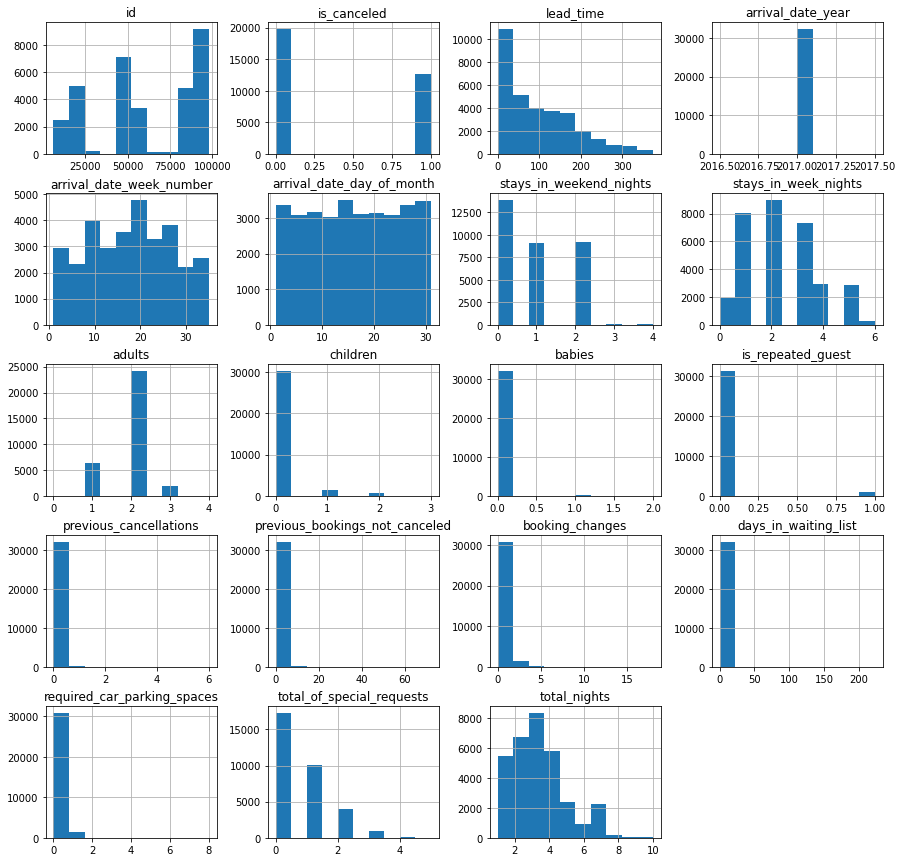

In [202]:
# Гистограмма для датасета с тестовой выборкой
data_test.hist(figsize=(15, 15));

In [203]:
# Дополнительно выведим общую информацию
data_test.describe().T

,count,mean,std,min,25%,50%,75%,max
id,32412.0,60131.505183,29953.586177,6086.0,45291.75,53394.5,89800.25,97903.0
is_canceled,32412.0,0.388467,0.487409,0.0,0.00,0.0,1.00,1.0
lead_time,32412.0,97.587869,86.507146,0.0,23.00,76.0,155.00,373.0
arrival_date_year,32412.0,2017.000000,0.000000,2017.0,2017.00,2017.0,2017.00,2017.0
arrival_date_week_number,32412.0,17.804054,9.177384,1.0,10.00,18.0,25.00,35.0
arrival_date_day_of_month,32412.0,15.656948,8.766429,1.0,8.00,15.5,23.00,31.0
stays_in_weekend_nights,32412.0,0.867888,0.853394,0.0,0.00,1.0,2.00,4.0
stays_in_week_nights,32412.0,2.340090,1.375170,0.0,1.00,2.0,3.00,6.0
adults,32412.0,1.858602,0.489341,0.0,2.00,2.0,2.00,4.0
children,32412.0,0.083765,0.343470,0.0,0.00,0.0,0.00,3.0


В тестовой выборке представлены данные за неполный 2017 г. Распределение количественных признаков в целом нормальное.  
Также есть выбросы и аномалии:

* lead_time (количество дней между датой бронирования и датой прибытия) - max значение 373 дней
* adults (взрослые) - есть 0, что странно, дети и младенцы не могут бронировать номера в отеле без взрослых 
* days_in_waiting_list (сколько дней заказ ожидал подтверждения) - max значение 223
* required_car_parking_spaces (необходимость места для автомобиля) - max значение 8, вряд ли кому-то могло понадобиться сразу столько парковочных мест

В тестовой выборке обрабатывать выбросы и аномалии не будем, так как нам нужны все наблюдения из выборки для получения предсказаний обученной модели.

**Рассмотрим выбросы в количественных признаках.**  

Начнем с количественного признака adults (взрослые)

In [206]:
# Сгруппируем данные по признаку adults в обучающем датасете
adults_count = data_train['adults'].value_counts()
adults_count

2    48980
1    13212
3     2858
0      166
4       13
Name: adults, dtype: int64

In [207]:
# 166 нулей, удалим их
data_train = data_train[data_train['adults'] != 0]

In [208]:
# Проверим внесенные изменения
adults_count = data_train['adults'].value_counts()
adults_count

2    48980
1    13212
3     2858
4       13
Name: adults, dtype: int64

In [212]:
# Сгруппируем данные по признаку babies в обучающем датасете
babies_count = data_train['babies'].value_counts()
babies_count

0     64614
1       444
2         3
9         1
10        1
Name: babies, dtype: int64

In [213]:
# Удалим все значения в 'babies', что больше 3
data_train = data_train[data_train['babies'] < 3]

In [214]:
# Проверим внесенные изменения
babies_count = data_train['babies'].value_counts()
babies_count

0    64614
1      444
2        3
Name: babies, dtype: int64

Рассмотрим выбросы в lead_time (количество дней между датой бронирования и датой прибытия) с помощью диаграмы размаха

<AxesSubplot:title={'center':'Количество дней между датой бронирования и прибытия'}>

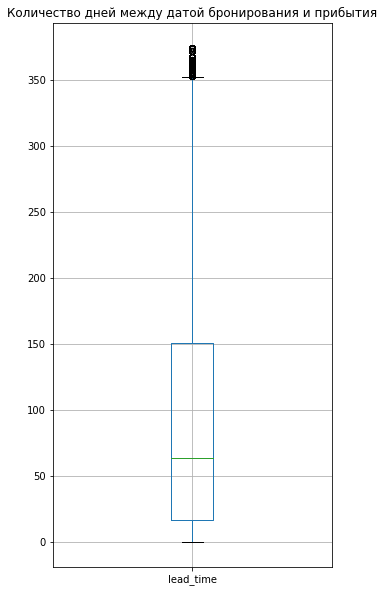

In [219]:
data_train['lead_time'].plot(kind='box',
                             figsize=(5,10), 
                             grid=True, 
                             legend=True, 
                             title='Количество дней между датой бронирования и прибытия')

In [220]:
# Удалим все значения в 'lead_time', что больше 350
data_train = data_train[data_train['lead_time'] < 350]

Рассмотрим выбросы в days_in_waiting_list (количество дней ожидания подтверждения заказа) с помощью диаграммы размаха

<AxesSubplot:title={'center':'Количество дней ожидания подтверждения заказа'}>

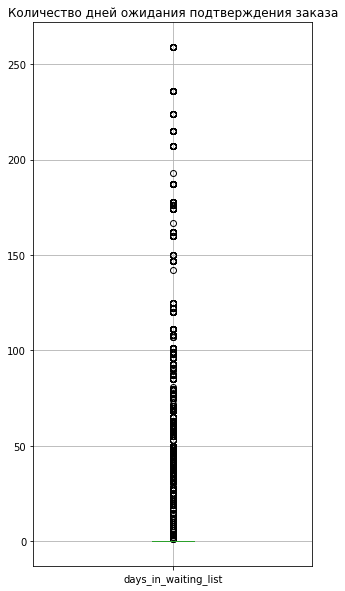

In [223]:
data_train['days_in_waiting_list'].plot(kind='box',
                             figsize=(5,10), 
                             grid=True, 
                             legend=True, 
                             title='Количество дней ожидания подтверждения заказа')

In [224]:
# Удалим все значения в 'days_in_waiting_list', что больше 100
data_train = data_train[data_train['days_in_waiting_list'] < 100]

**Рассмотрим категориальные признаки** 
   
Начнем с customer_type — тип заказчика:  
Contract — договор с юридическим лицом;  
Group — групповой заезд;  
Transient — не связано с договором или групповым заездом;  
Transient-party — не связано с договором или групповым заездом, но связано с бронированием типа Transient.  

In [227]:
data_train['customer_type'].unique()

array(['Transient', 'Contract', 'Transient-Party', 'Group'], dtype=object)

In [228]:
data_test['customer_type'].unique()

array(['Transient', 'Transient-Party', 'Contract', 'Group'], dtype=object)

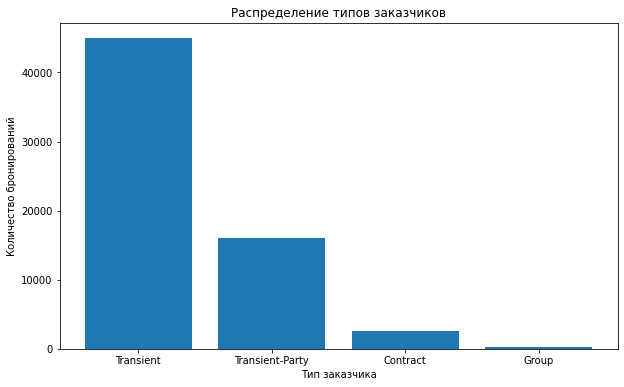

In [229]:
customer_type_count = data_train['customer_type'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(customer_type_count.index, customer_type_count.values)
plt.xlabel('Тип заказчика')
plt.ylabel('Количество бронирований')
plt.title('Распределение типов заказчиков')
plt.show()

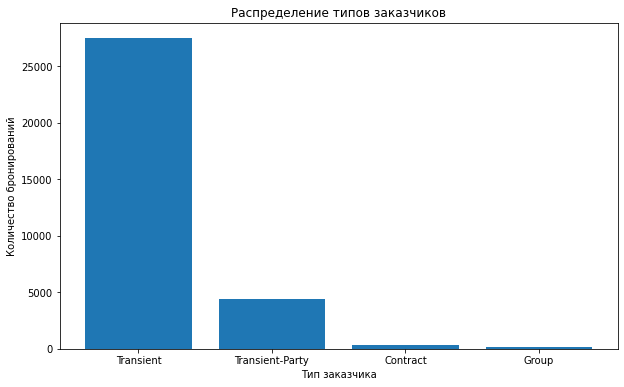

In [230]:
customer_type_count = data_test['customer_type'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(customer_type_count.index, customer_type_count.values)
plt.xlabel('Тип заказчика')
plt.ylabel('Количество бронирований')
plt.title('Распределение типов заказчиков')
plt.show()

В обоих датасетах большинство клиентов относятся к типу Transient (не связаны с договором или групповым заездом)

Рассмотрим следующий категориальный признак meal (опции заказа):  
SC — нет дополнительных опций;  
BB — включён завтрак;  
HB — включён завтрак и обед;  
FB — включён завтрак, обед и ужин.  

In [231]:
data_train['meal'].unique()

array(['BB       ', 'FB       ', 'HB       ', 'SC       ', 'SC'],
      dtype=object)

In [232]:
data_test['meal'].unique()

array(['BB       ', 'HB       ', 'SC', 'FB       ', 'SC       '],
      dtype=object)

В обоих датасетах в колонке со значениями 'meal' есть лишние пробелы, их нужно удалить

In [233]:
data_train['meal'] = data_train['meal'].str.strip()
data_test['meal'] = data_test['meal'].str.strip()

In [234]:
# Проверяем внесенные изменения
data_train['meal'].unique()

array(['BB', 'FB', 'HB', 'SC'], dtype=object)

In [235]:
# Проверяем внесенные изменения
data_test['meal'].unique()

array(['BB', 'HB', 'SC', 'FB'], dtype=object)

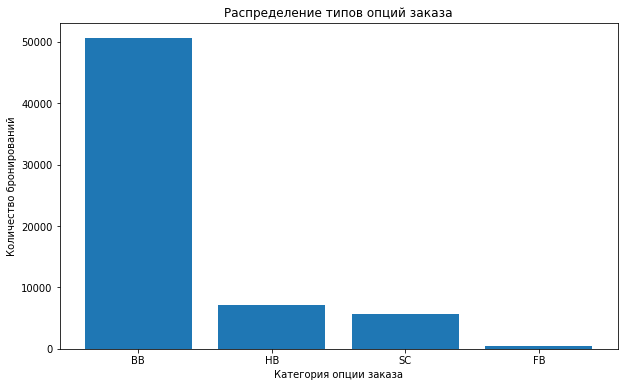

In [236]:
meal_count = data_train['meal'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(meal_count.index, meal_count.values)
plt.xlabel('Категория опции заказа')
plt.ylabel('Количество бронирований')
plt.title('Распределение типов опций заказа')
plt.show()

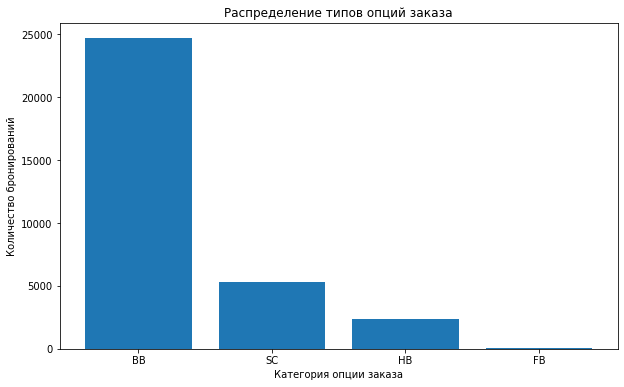

In [237]:
meal_count = data_test['meal'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(meal_count.index, meal_count.values)
plt.xlabel('Категория опции заказа')
plt.ylabel('Количество бронирований')
plt.title('Распределение типов опций заказа')
plt.show()

 Большинство клиентов предпочитают заказывать опцию BB (включён завтрак)

Рассмотрим reserved_room_type (тип забронированной комнаты):  
  
категория A: за ночь — 1 000, разовое обслуживание — 400;  
категория B: за ночь — 800, разовое обслуживание — 350;  
категория C: за ночь — 600, разовое обслуживание — 350;  
категория D: за ночь — 550, разовое обслуживание — 150;  
категория E: за ночь — 500, разовое обслуживание — 150;  
категория F: за ночь — 450, разовое обслуживание — 150;  
категория G: за ночь — 350, разовое обслуживание — 150.  

In [238]:
data_train['reserved_room_type'].unique()

array(['A               ', 'C               ', 'D               ',
       'E               ', 'G               ', 'F               ',
       'B               '], dtype=object)

In [239]:
data_test['reserved_room_type'].unique()

array(['A               ', 'E               ', 'G               ',
       'D               ', 'F               ', 'C               ',
       'B               '], dtype=object)

В обоих датасетах в колонке со значениями 'reserved_room_type' есть лишние пробелы, их нужно удалить

In [240]:
data_train['reserved_room_type'] = data_train['reserved_room_type'].str.strip()
data_test['reserved_room_type'] = data_test['reserved_room_type'].str.strip()

In [241]:
# Проверяем внесенные изменения
data_train['reserved_room_type'].unique()

array(['A', 'C', 'D', 'E', 'G', 'F', 'B'], dtype=object)

In [242]:
# Проверяем внесенные изменения
data_test['reserved_room_type'].unique()

array(['A', 'E', 'G', 'D', 'F', 'C', 'B'], dtype=object)

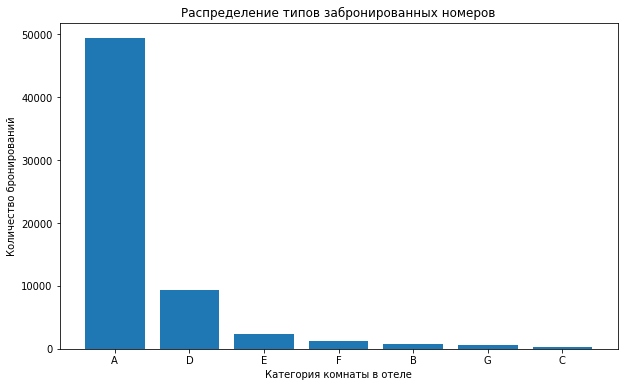

In [243]:
reserved_room_type_count = data_train['reserved_room_type'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(reserved_room_type_count.index, reserved_room_type_count.values)
plt.xlabel('Категория комнаты в отеле')
plt.ylabel('Количество бронирований')
plt.title('Распределение типов забронированных номеров')
plt.show()

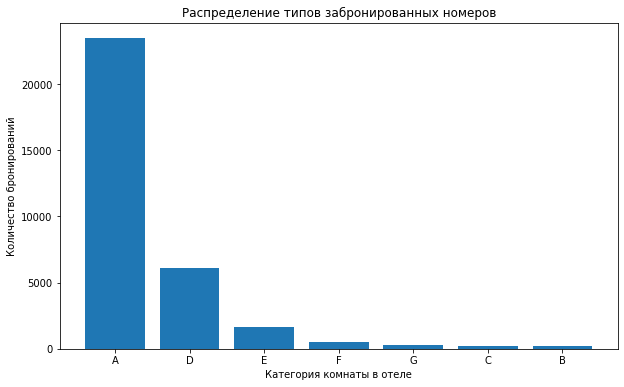

In [244]:
reserved_room_type_count = data_test['reserved_room_type'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(reserved_room_type_count.index, reserved_room_type_count.values)
plt.xlabel('Категория комнаты в отеле')
plt.ylabel('Количество бронирований')
plt.title('Распределение типов забронированных номеров')
plt.show()

Большинство клиентов чаще всего заказывают номера категории A (ночь — 1000 руб, разовое обслуживание — 400 руб)

Рассмотрим distribution_channel (каналы дистрибуции заказа)

In [245]:
data_train['distribution_channel'].unique()

array(['Direct', 'TA/TO', 'Corporate', 'GDS'], dtype=object)

In [246]:
data_test['distribution_channel'].unique()

array(['TA/TO', 'Direct', 'Corporate', 'GDS'], dtype=object)

Посмотрим распределение данных 'distribution_channel' с помощью столбчатой диаграммы

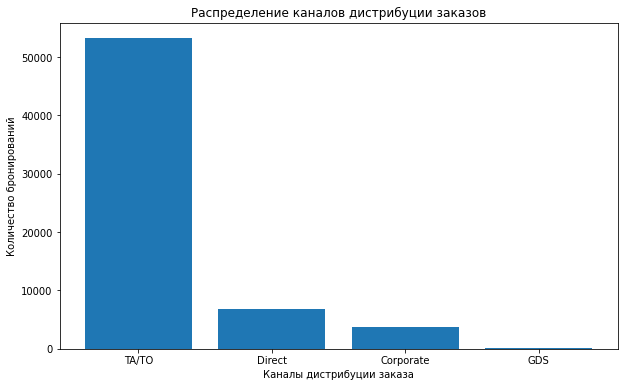

In [247]:
distribution_channel_count = data_train['distribution_channel'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(distribution_channel_count.index, distribution_channel_count.values)
plt.xlabel('Каналы дистрибуции заказа')
plt.ylabel('Количество бронирований')
plt.title('Распределение каналов дистрибуции заказов')
plt.show()

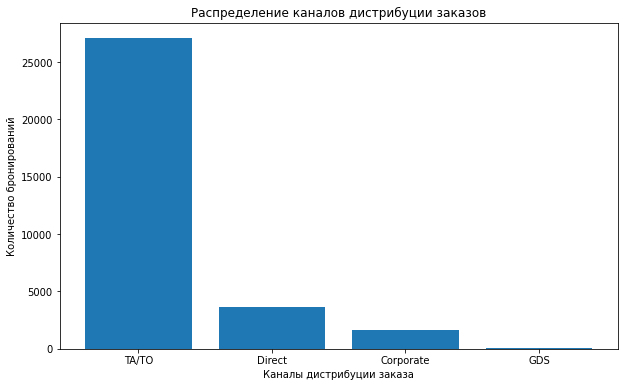

In [248]:
distribution_channel_count = data_test['distribution_channel'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(distribution_channel_count.index, distribution_channel_count.values)
plt.xlabel('Каналы дистрибуции заказа')
plt.ylabel('Количество бронирований')
plt.title('Распределение каналов дистрибуции заказов')
plt.show()

Основной канал дистрибуции заказов - TA/TO

Рассмотрим последний категориальный признак country — гражданство постояльца

In [249]:
data_train['country'].unique()

array(['GBR', 'PRT', 'ESP', 'IRL', 'FRA', 'ROU', 'NOR', 'USA', 'DEU',
       'BEL', 'CHE', 'CN', 'GRC', 'NLD', 'ARG', 'RUS', 'SWE', 'POL',
       'EST', 'CZE', 'ITA', 'FIN', 'DNK', 'MOZ', 'BWA', 'LUX', 'BRA',
       'SVN', 'ALB', 'CHN', 'MEX', 'MAR', 'SMR', 'LVA', 'CHL', 'AUT',
       'LTU', 'TUR', 'ISR', 'IND', 'CYM', 'AUS', 'CPV', 'ZWE', 'DZA',
       'KOR', 'CRI', 'HUN', 'TUN', 'ARE', 'HRV', 'HKG', 'IRN', 'GIB',
       'JEY', 'URY', 'ZAF', 'COL', 'GGY', 'KWT', 'CYP', 'KAZ', 'THA',
       'DOM', 'NGA', 'BLR', 'VEN', 'UKR', 'ARM', 'JPN', 'LKA', 'MYS',
       'BIH', 'MUS', 'OMN', 'SUR', 'JAM', 'BGR', 'CIV', 'SRB', 'JOR',
       'SYR', 'PHL', 'PRI', 'SGP', 'BDI', 'LBN', 'AGO', 'VNM', 'AZE',
       'PLW', 'NZL', 'EGY', 'MDV', 'CMR', 'MLT', 'SVK', 'MWI', 'STP',
       'TWN', 'IDN', 'SEN', 'PER', 'SAU', 'KNA', 'ETH', 'ECU', 'IRQ',
       'AND', 'HND', 'PAK', 'GEO', 'ZMB', 'QAT', 'KHM', 'MCO', 'BGD',
       'UZB', 'IMN', 'TJK', 'NIC', 'ISL', 'BEN', 'MAC', 'VGB', 'TZA',
       'GAB', 'MKD', 

In [250]:
data_test['country'].unique()

array(['PRT', 'AUT', 'BEL', 'DEU', 'BRA', 'GBR', 'ESP', 'FRA', 'ITA',
       'LUX', 'CHE', 'EST', 'NGA', 'IRL', 'CN', 'POL', 'AUS', 'NLD',
       'KOR', 'ROU', 'USA', 'CHL', 'DNK', 'FIN', 'RUS', 'SWE', 'HUN',
       'HRV', 'MDV', 'ZAF', 'ISR', 'NOR', 'CHN', 'ARE', 'MAR', 'COL',
       'FJI', 'LVA', 'LBN', 'PHL', 'HKG', 'SYC', 'GIB', 'AGO', 'MYS',
       'MDG', 'IDN', 'LTU', 'ISL', 'TUR', 'ARG', 'JPN', 'SVN', 'SVK',
       'BGR', 'CAF', 'JAM', 'UZB', 'UKR', 'IND', 'CZE', 'URY', 'NZL',
       'NPL', 'SRB', 'CPV', 'IRN', 'KAZ', 'BHS', 'SUR', 'CUB', 'PAK',
       'MAC', 'CYP', 'JOR', 'GRC', 'KWT', 'TWN', 'VNM', 'SGP', 'DOM',
       'VEN', 'SEN', 'BLR', 'TZA', 'LIE', 'GNB', 'SAU', 'DZA', 'PER',
       'AZE', 'EGY', 'ETH', 'KEN', 'THA', 'MLT', 'ECU', 'AND', 'IMN',
       'BHR', 'TUN', 'MNE', 'MEX', 'BEN', 'MOZ', 'UMI', 'JEY', 'MYT',
       'QAT', 'BGD', 'GAB', 'CIV', 'ZWE', 'GTM', 'ALB', 'GHA', 'ATA',
       'ASM', 'PAN', 'CRI', 'MCO', 'MUS', 'SYR', 'TGO', 'IRQ', 'LKA',
       'BIH', 'PRY', 

In [251]:
country_grouped = data_train.groupby('country')['country'].count().sort_values(ascending=False)
country_grouped

country
PRT    27895
FRA     5910
GBR     5006
ESP     4885
DEU     3818
       ...  
NIC        1
PLW        1
PRY        1
PYF        1
ZWE        1
Name: country, Length: 155, dtype: int64

In [252]:
country_grouped_1 = data_test.groupby('country')['country'].count().sort_values(ascending=False)
country_grouped_1

country
PRT    9887
GBR    3927
FRA    3477
DEU    2378
ESP    1932
       ... 
SLV       1
STP       1
IMN       1
NCL       1
ABW       1
Name: country, Length: 143, dtype: int64

Большинство постояльцев отеля граждане Португалии, Великобритании и Франции

In [253]:
data_train.duplicated().sum()

0

In [254]:
data_test.duplicated().sum()

0

**Проверим корреляцию признаков.** 
  
При высокой степени коррелированности признаков может возникнуть проблема с обучением моделей (мультиколлиниарность признаков). Особенно критична эта проблема может быть для линейных моделей (мультиколлиниарности признаков делает такие модели непригодными для прогнозирования).  

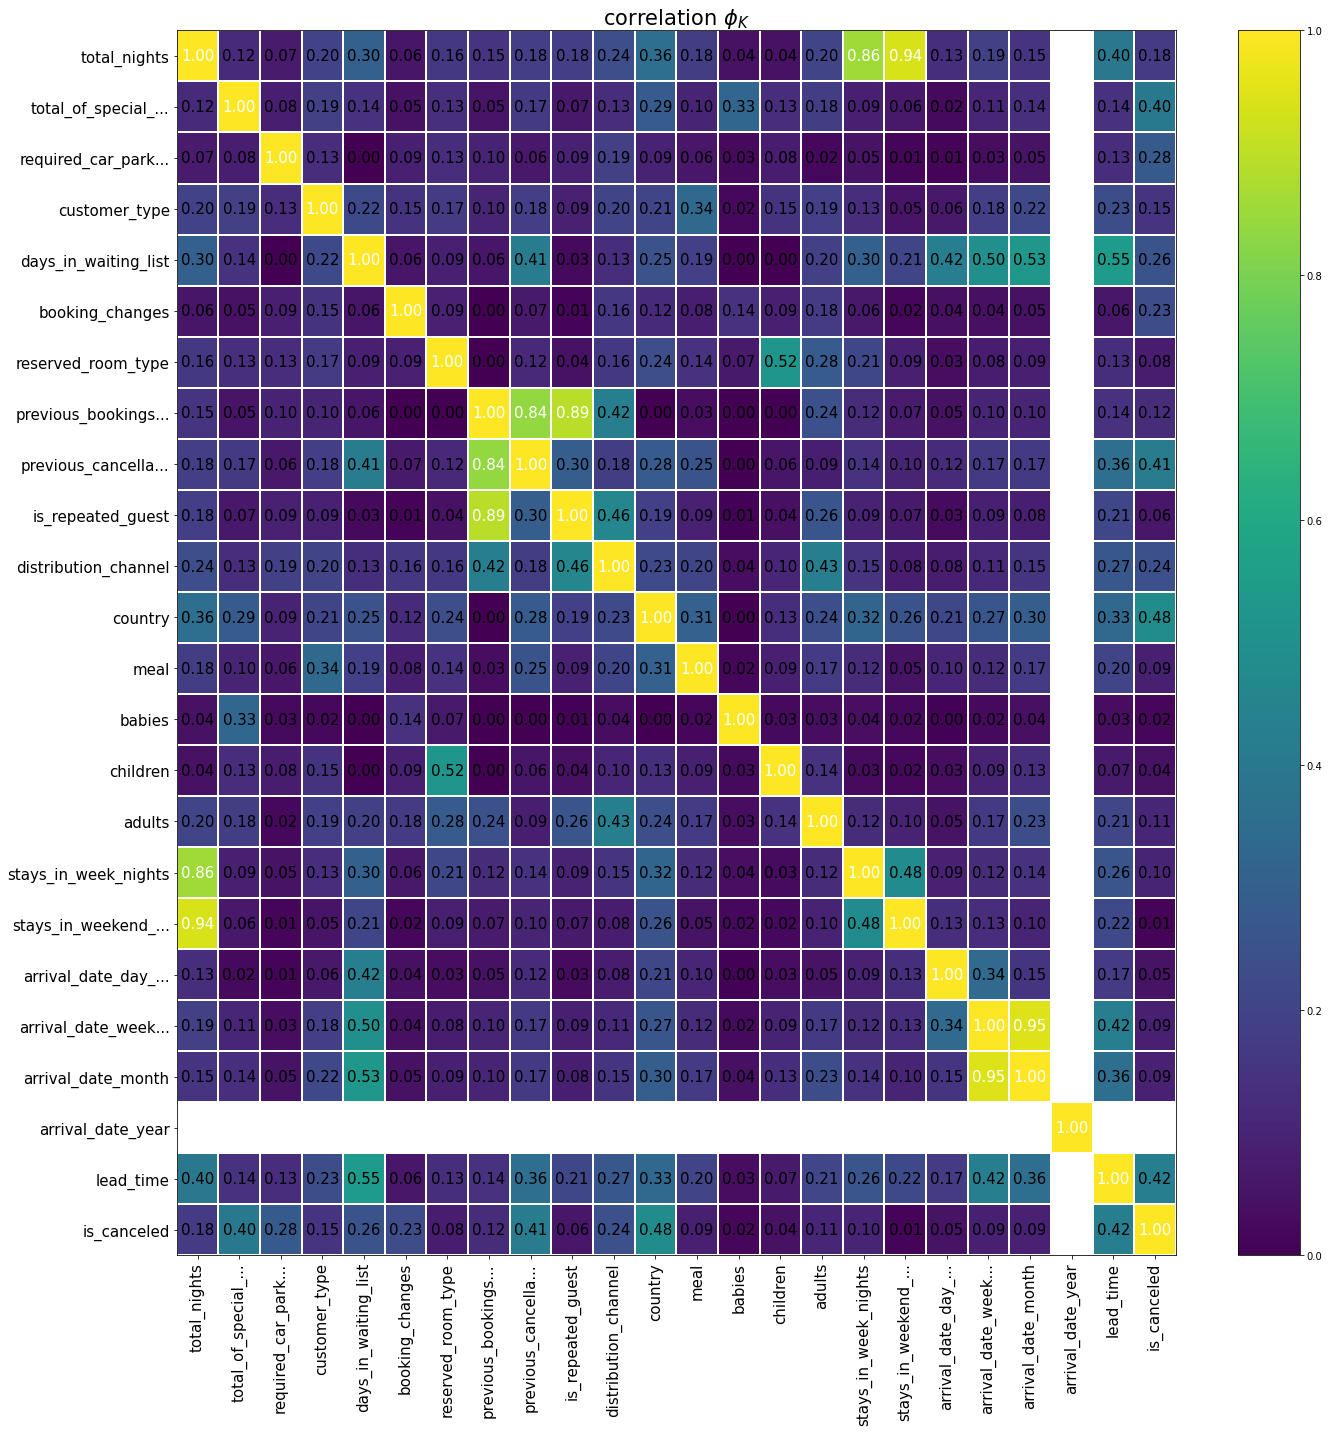

In [258]:
data_train_without_id = data_train.drop(['id'], axis=1)

interval_cols = ['arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'lead_time']

phik_overview = data_train_without_id.phik_matrix(interval_cols=interval_cols)

plot_correlation_matrix(phik_overview.values, 
                        x_labels=phik_overview.columns, 
                        y_labels=phik_overview.index, 
                        vmin=0, vmax=1, color_map="viridis",
                        title=r"correlation $\phi_K$", 
                        fontsize_factor=1.5, 
                        figsize=(20, 20))
plt.tight_layout()

Обнаружена корреляция между признаками:

* previous_bookings_not_canceled и 'previous_cancellations' - 0.84

* previous_bookings_not_canceled и is_repeated_guest - 0.89

* arrival_date_month и arrival_date_week_number - 0.95

Удалим лишние столбцы, которые не понадобяться на этапе обучения моделей:


* id (номер записи) - не несет никакой важной информации

* arrival_date_day_of_month (день заезда) - не несет никакой важной информации

* arrival_date_year (год заезда) - скорее всего не понадобится, так как в одном датасете с обучающей выборкой у нас данные за 2015-2016 гг,  в другом датасете с тестовой выборкой - данные за неполный 2017 г, итоговая модель должна предсказывает отмену в текущем году.

* total_nights (общее количество ночей) - мы обнаружили корреляцию этого признака с двумя другими в обоих датасетах: 'stays_in_weekend_nights','stays_in_week_nights', их лучше удалить. 

* previous_bookings_not_canceled (количество подтверждённых заказов у клиента) - признак, связан с 'previous_cancellations' и 'is_repeated_guest'

* arrival_date_week_number - признак, связанный с arrival_date_month (месяц заезда)

In [260]:
columns_to_drop = ['id', 'arrival_date_year', 'arrival_date_day_of_month', 'total_nights', 
                   'previous_bookings_not_canceled', 'arrival_date_week_number']

In [261]:
data_train = data_train.drop(columns=columns_to_drop, axis=1)
data_test = data_test.drop(columns=columns_to_drop, axis=1)

In [262]:
data_train.duplicated().sum()

21295

In [263]:
data_test.duplicated().sum()

7963

После удаления ненужных признаков, в датасетах появились явные дубликаты, но в этом нет ничего подозрительного, можем допусить, что у многих клиенов отеля может быть одинаковый набор данных.

In [264]:
data_train = data_train.drop_duplicates()

In [265]:
data_train.duplicated().sum()

0

In [266]:
data_train.head()

,is_canceled,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,distribution_channel,is_repeated_guest,previous_cancellations,reserved_room_type,booking_changes,days_in_waiting_list,customer_type,required_car_parking_spaces,total_of_special_requests
0,0,7,July,0,1,1,0,0,BB,GBR,Direct,0,0,A,0,0,Transient,0,0
1,0,14,July,0,2,2,0,0,BB,GBR,TA/TO,0,0,A,0,0,Transient,0,1
2,0,0,July,0,2,2,0,0,BB,PRT,Direct,0,0,C,0,0,Transient,0,0
3,0,9,July,0,2,2,0,0,FB,PRT,Direct,0,0,C,0,0,Transient,0,1
4,1,85,July,0,3,2,0,0,BB,PRT,TA/TO,0,0,A,0,0,Transient,0,1


In [267]:
# Проверим, сколько данных осталось после всех внесенных изменений в обоих датасетах. Изначально было 65229 и 32412
print(data_train.shape)
print(data_test.shape)

(42569, 19)
(32412, 19)


### Вывод

На данном этапе исследования была проведена предобработка и исследовательский анализ данных:  

* Проверили данные на пропуски и явные дубликаты (не были обнаружены)  

* Изменили тип данных столбцах 'lead_time', 'adults', 'children', 'babies' с float на int  

* Удалили аномальные значения и выбросы в данных: adults, babies, equired_car_parking_spaces, lead_time, days_in_waiting_list  
  
* Удалили лишние пробелы в колонках meal и reserved_room_type  
  
* Проверили корреляцию признаков. Обнаружили взаимосвязь между признаками stays_in_week_nights (количество ночей в будние дни) и total_nights (общее количество ночей), между stays_in_weekend_nights (количество ночей в выходные дни) и total_nights, 
между previous_bookings_not_canceled и'previous_cancellations', 'is_repeated_guest', а так же между arrival_date_month и arrival_date_week_number

* Удалили лишние столбцы, которые не понадобяться на этапе обучения моделей: 'id', 'arrival_date_year', 'arrival_date_day_of_month', 'total_nights', 'previous_bookings_not_canceled', 'arrival_date_week_number'

* После удаления признаков, проверили датасет с обучающей выборкой на явные дубликаты и удалили их.

## Формулировка ML-задачи на основе бизнес-задачи

### Оценка прибыли отеля без внедрения депозитов.

Бизнес-метрика и другие данные:  
  
Основная бизнес-метрика для любой сети отелей — её прибыль. Прибыль отеля — это разница между стоимостью номера за все ночи и затраты на обслуживание: как при подготовке номера, так и при проживании постояльца.   
В отеле есть несколько типов номеров. В зависимости от типа номера назначается стоимость за одну ночь. Есть также затраты на уборку. Если клиент снял номер надолго, то убираются каждые два дня.   

Стоимость номеров отеля:  
категория A: за ночь — 1 000, разовое обслуживание — 400;  
категория B: за ночь — 800, разовое обслуживание — 350;  
категория C: за ночь — 600, разовое обслуживание — 350;  
категория D: за ночь — 550, разовое обслуживание — 150;  
категория E: за ночь — 500, разовое обслуживание — 150;  
категория F: за ночь — 450, разовое обслуживание — 150;  
категория G: за ночь — 350, разовое обслуживание — 150.  
  
В ценовой политике отеля используются сезонные коэффициенты: весной и осенью цены повышаются на 20%, летом — на 40%.  
Убытки отеля в случае отмены брони номера — это стоимость одной уборки и одной ночи с учётом сезонного коэффициента.
На разработку системы прогнозирования заложен бюджет — 400 000. При этом необходимо учесть, что внедрение модели должно окупиться за тестовый период. Затраты на разработку должны быть меньше той выручки, которую система принесёт компании.  

In [268]:
columns = ['reserved_room_type' , 'room_price', 'room_prepare']
data = [['A', 1000, 400],['B', 800, 350], ['C', 600, 350], ['D', 550, 150], 
        ['E', 500, 150], ['F', 450, 150], ['G', 350, 150]]
room_data = pd.DataFrame(data=data, columns = columns)

In [269]:
pd.options.display.max_columns=99
data_test

,is_canceled,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,distribution_channel,is_repeated_guest,previous_cancellations,reserved_room_type,booking_changes,days_in_waiting_list,customer_type,required_car_parking_spaces,total_of_special_requests
0,1,74,January,1,0,2,0,0,BB,PRT,TA/TO,0,0,A,0,0,Transient,0,0
1,1,62,January,2,2,2,0,0,BB,AUT,TA/TO,0,0,A,0,0,Transient,0,1
2,1,62,January,2,2,2,0,0,BB,AUT,TA/TO,0,0,A,0,0,Transient,0,1
3,1,71,January,2,2,1,0,0,BB,PRT,TA/TO,0,0,A,0,0,Transient,0,1
4,1,172,January,2,5,2,0,0,BB,BEL,TA/TO,0,0,A,0,0,Transient,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32407,0,164,August,2,4,2,0,0,BB,DEU,TA/TO,0,0,A,0,0,Transient,0,0
32408,0,21,August,2,5,2,0,0,BB,BEL,TA/TO,0,0,A,0,0,Transient,0,2
32409,0,23,August,2,5,2,0,0,BB,BEL,TA/TO,0,0,A,0,0,Transient,0,0
32410,0,34,August,2,5,2,0,0,BB,DEU,TA/TO,0,0,D,0,0,Transient,0,4


In [172]:
summer = ['June', 'July', 'August']
winter = ['December', 'January', 'February']

def count_revenue(row):
    room_type = row['reserved_room_type']
    month = row['arrival_date_month']
    week_nights = row['stays_in_week_nights']
    weekend_nights = row['stays_in_weekend_nights']
    price = room_data[room_data['reserved_room_type'] == room_type]['room_price'].median()
    prepare_cost = room_data[room_data['reserved_room_type'] == room_type]['room_prepare'].median()

    total_nights = week_nights + weekend_nights
    prepare_nights = (total_nights + 1) // 2

    if (row['is_canceled'] == 0):
        if (month in summer):
            revenue = 1.4 * price * total_nights - prepare_cost - prepare_nights * prepare_cost
        elif (month in winter):
            revenue = price * total_nights - prepare_cost - prepare_nights * prepare_cost
        else:
            revenue = 1.2 * price * total_nights - prepare_cost - prepare_nights * prepare_cost
    else:
        revenue = -prepare_cost
    return revenue

Подсчитаем прибыль отеля без внедрения депозитов на тестовой выборке:

In [173]:
total_revenue = data_test.apply(count_revenue, axis=1).sum()
print(total_revenue)

42534180.0


### Вывод

Таким образом, прибыль на тестовой выборке за отчестный период (неполный 2017 г) у нас составила 42.53 млн. руб.   
Далее приступим к обучению ML моделей.

## Разработка модели ML

Обучите разные модели и оцените их качество кросс-валидацией. Выберите лучшую модель и проверьте её на тестовой выборке. Опишите выводы.
Выберите метрику для обучения.  
Оцените прибыль, которую принесёт выбранная модель за год.  

Целевой признак - 'is_canceled' (отмена заказа).
Нам предстоит решать задачу классификации: определить будет ли отменена бронь или нет.

Для нас в большей степени важно предсказать отмену брони, потому что в случае, если мы предскажем её ошибочно и возмём с клиента предоплату, она пойдёт в счёт общего платежа по выселении. Поэтому тут стоит оринетироваться на метрику **recall** - она покажет, как хорошо модель способна идентифицировать и предсказывать отмену бронирования, то есть, насколько точно модель сможет обнаружить и уловить все случаи отмены бронирования.

In [270]:
# Разделяем выборки по признакам (целевой и прочие)

features_train = data_train.drop(['is_canceled'], axis=1)
target_train = data_train['is_canceled']

features_test = data_test.drop(['is_canceled'], axis=1)
target_test = data_test['is_canceled']

print("Размер обучающей выборки:", features_train.shape)
print("Размер тестовой выборки:", features_test.shape)
print("Размер обучающей выборки:", target_train.shape)
print("Размер тестовой выборки:", target_test.shape)

Размер обучающей выборки: (42569, 18)
Размер тестовой выборки: (32412, 18)
Размер обучающей выборки: (42569,)
Размер тестовой выборки: (32412,)


В датасетах есть категориальные признаки, перед обучением моделей их стоит преобразовать в количественные.  
Применим технику OneHotEncoder.

In [272]:
# Создаем OneHotEncoder с параметрами drop='first'
encoder = OneHotEncoder(drop='first', sparse=False, handle_unknown='ignore')

In [274]:
categorical_features = ['distribution_channel', 'customer_type', 'meal', 
                        'country', 'reserved_room_type', 'arrival_date_month']

In [275]:
# Создаем объект ColumnTransformer для применения кодирования к категориальным признакам
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', encoder, categorical_features)
    ],
    remainder='passthrough'
)

# Применяем препроцессор к обучающей и тестовой выборке
features_train_encoded = preprocessor.fit_transform(features_train)
features_test_encoded = preprocessor.transform(features_test)

print("Размер обучающей выборки:", features_train_encoded.shape)
print("Размер тестовой выборки:", features_test_encoded.shape)

Размер обучающей выборки: (42569, 192)
Размер тестовой выборки: (32412, 192)


In [279]:
# Преобразовываем категориальные признаки в количественные для тренировочной выборки (features_train)
train_encoded_features = encoder.fit_transform(features_train[categorical_features])
train_encoded_df = pd.DataFrame(train_encoded_features, columns=encoder.get_feature_names(categorical_features))

# Преобразовываем категориальные признаки в количественные для тестовой выборки (features_test)
test_encoded_features = encoder.transform(features_test[categorical_features])
test_encoded_df = pd.DataFrame(test_encoded_features, columns=encoder.get_feature_names(categorical_features))

In [287]:
train_data_encoded = pd.concat([train_encoded_df.reset_index(drop=True), 
                                features_train.select_dtypes(include='number').reset_index(drop=True), 
                                pd.DataFrame({'is_canceled_encoded': target_train}).reset_index(drop=True)], axis=1)
test_data_encoded = pd.concat([test_encoded_df.reset_index(drop=True), 
                               features_test.select_dtypes(include='number').reset_index(drop=True), 
                               pd.DataFrame({'is_canceled_encoded': target_test}).reset_index(drop=True)], axis=1)

print("Размер обучающей выборки:", train_data_encoded.shape)
print("Размер тестовой выборки:", test_data_encoded.shape)

Размер обучающей выборки: (42569, 193)
Размер тестовой выборки: (32412, 193)


In [288]:
train_data_encoded.isna().sum()

distribution_channel_Direct    0
distribution_channel_GDS       0
distribution_channel_TA/TO     0
customer_type_Group            0
customer_type_Transient        0
                              ..
booking_changes                0
days_in_waiting_list           0
required_car_parking_spaces    0
total_of_special_requests      0
is_canceled_encoded            0
Length: 193, dtype: int64

In [318]:
test_data_encoded.isna().sum()

distribution_channel_Direct    0
distribution_channel_GDS       0
distribution_channel_TA/TO     0
customer_type_Group            0
customer_type_Transient        0
                              ..
booking_changes                0
days_in_waiting_list           0
required_car_parking_spaces    0
total_of_special_requests      0
is_canceled_encoded            0
Length: 193, dtype: int64

### Модель: Решающее дерево

Обучим первую модель Решающее дерево (DecisionTreeClassifier)

In [295]:
# Определим параметры
param_grid = {
    'max_depth': range(1, 15),
    'class_weight': ['balanced'],
}

# Создадим модель Дерева решений
tree_model = DecisionTreeClassifier(random_state=12345)

# Создадим объект GridSearchCV
grid_search = GridSearchCV(tree_model, param_grid, cv=5, scoring='recall')
grid_search.fit(features_train_encoded, target_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f'Лучшие параметры: {best_params}, Лучшая оценка качества модели: {best_score}')

Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 1}, Лучшая оценка качества модели: 0.8334849863512283


### Модель: Случайный лес

Обучим следующую модель - Случайный лес (RandomForestClassifier)

In [299]:
# Определим параметры
param_grid = {
    'n_estimators': range(10, 101, 10),
    'max_depth': range(1, 15),
    'class_weight': ['balanced'],
}

# Создадим модель Случайного леса
forest_model = RandomForestClassifier(random_state=12345)

# Создадим объект GridSearchCV
grid_search = GridSearchCV(forest_model, param_grid, cv=5, scoring='recall')
grid_search.fit(features_train_encoded, target_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f'Лучшая глубина: {best_params["max_depth"]}, Лучшее количество деревьев: {best_params["n_estimators"]}, Лучшая оценка качества модели: {best_score}')

Лучшая глубина: 2, Лучшее количество деревьев: 10, Лучшая оценка качества модели: 0.691901728844404


### Модель: Логистическая регрессия

Обучим последнюю модель - Логистическую регрессию (LogisticRegression)

In [300]:
model_log = LogisticRegression(random_state=12345, 
                               max_iter=1000, 
                               solver='liblinear', 
                               class_weight='balanced')

# < посчитайте оценки, вызвав функцию cross_value_score с пятью блоками >
scores = cross_val_score(model_log, train_data_encoded.drop(['is_canceled_encoded'], axis=1), 
                         train_data_encoded['is_canceled_encoded'], cv=5, scoring='recall')

# Вычислим среднее значение оценок
final_score = sum(scores) / len(scores)

print('Средняя оценка качества модели:', final_score)

Средняя оценка качества модели: 0.47534121929026385


Таким образом, лучшая модель - Решающее дерево (лучшая оценка качества модели: 0.83 при max_depth=1). 

  
Теперь проверим эту модель на тестовой выборке.   
В качестве метрики оценки качества будем использовать recall и метрику AUC-ROC.     
Метрика AUC-ROC показывает, как сильно наша модель отличается от случайной, так как AUC-ROC случайной модели равна 0.5. 

### Обучение лучшей модели (DecisionTreeClassifier) на тестовой выборке

recall_score: 0.9647367167024065
auc_roc: 0.5928320080157005


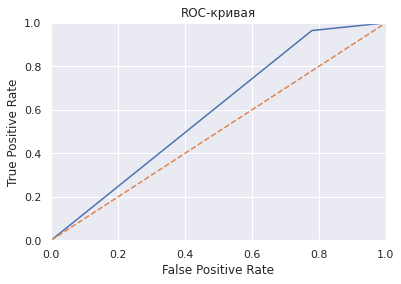

In [303]:
# Обучаем лучшую модель на всей обучающей выборке
model = DecisionTreeClassifier(random_state=12345, max_depth=1, class_weight='balanced')
model.fit(train_data_encoded.drop(['is_canceled_encoded'], axis=1), train_data_encoded['is_canceled_encoded'])

# Получаем предсказания на тестовой выборке
test_predictions = model.predict(test_data_encoded.drop(['is_canceled_encoded'], axis=1))

# Вычисляем recall
recall = recall_score(test_data_encoded['is_canceled_encoded'], test_predictions)

# Вычисляем auc_roc
probabilities_test = model.predict_proba(test_data_encoded.drop(['is_canceled_encoded'], axis=1))
probabilities_one_test = probabilities_test[:, 1]
auc_roc = roc_auc_score(test_data_encoded['is_canceled_encoded'], probabilities_one_test)

print(f'recall_score: {recall}')
print(f'auc_roc: {auc_roc}')

# Дополнительно построим график AUC-ROC
sns.set(font_scale=1)
fpr, tpr, thresholds = roc_curve(test_data_encoded['is_canceled_encoded'], probabilities_one_test)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.show()

Модель решающего дерева при величине гиперпараметра max_depth=1 показывает на тестовой выборке следующие результаты:  

recall_score: 0.96  
auc_roc: 0.59  

### Оценим прибыль, которую принесет выбранная модель

In [304]:
#Сохраним предсказания модели в таблице data_test:
data_test['predictions'] = test_predictions
display(data_test.head())

,is_canceled,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,distribution_channel,is_repeated_guest,previous_cancellations,reserved_room_type,booking_changes,days_in_waiting_list,customer_type,required_car_parking_spaces,total_of_special_requests,predictions
0,1,74,January,1,0,2,0,0,BB,PRT,TA/TO,0,0,A,0,0,Transient,0,0,1
1,1,62,January,2,2,2,0,0,BB,AUT,TA/TO,0,0,A,0,0,Transient,0,1,1
2,1,62,January,2,2,2,0,0,BB,AUT,TA/TO,0,0,A,0,0,Transient,0,1,1
3,1,71,January,2,2,1,0,0,BB,PRT,TA/TO,0,0,A,0,0,Transient,0,1,1
4,1,172,January,2,5,2,0,0,BB,BEL,TA/TO,0,0,A,0,0,Transient,0,0,1


Теперь на основе функции count_revenue создадим функцию, которая подсчитает прибыль отеля с учетом введения депозитов:

In [305]:
summer = ['June', 'July', 'August']
winter = ['December', 'January', 'February']

def count_revenue_with_deposit(row):
    room_type = row['reserved_room_type']
    month = row['arrival_date_month']
    week_nights = row['stays_in_week_nights']
    weekend_nights = row['stays_in_weekend_nights']
    price = room_data[room_data['reserved_room_type'] == room_type]['room_price'].median()
    prepare_cost = room_data[room_data['reserved_room_type'] == room_type]['room_prepare'].median()
    total_nights = week_nights + weekend_nights
    if (row['predictions']==1):
        deposit = 0.8*price
    else:
        deposit = 0
    
    
    if (row['is_canceled'] == 0):
        
        prepare_nights = math.floor((total_nights-1)/2)
        

        if (month in summer):
            revenue = 1.4*price*total_nights - prepare_cost - prepare_nights*prepare_cost

        elif (month in winter):
            revenue = price*total_nights - prepare_cost - prepare_nights*prepare_cost

        else:
            revenue = 1.2 * price*total_nights - prepare_cost - prepare_nights*prepare_cost
    else:
        revenue = deposit - prepare_cost
    return revenue

In [306]:
total_revenue_deposit = data_test.apply(count_revenue_with_deposit, axis=1).sum()
print(total_revenue_deposit)

57651330.0


Теперь подсчитаем чистую прибыль отеля после введения системы депозитов с учетом стоимости разработки системы прогнозирования:

In [307]:
IMPLEMENTATION_COST = 400000
net_profit = total_revenue_deposit  - total_revenue - IMPLEMENTATION_COST
print(net_profit)

14717150.0


Таким образом, с учетом стоимости введения системы депозитов, отель за год получит дополнительно 14.71 млн. чистой прибыли

### Вывод

Отель до внедрения системы депозитов  в 2017 году получил прибыль 42.53 млн. руб.  

Лучшая модель - Решающее дерево при величине гиперпараметра max_depth=1 показывает на тестовой выборке следующие результаты:  
recall_score: 0.96  
auc_roc: 0.59  

Чистая прибыль после введения депозитов в 2017 году могла стать 57.65 млн. руб.  
C учетом стоимости введения системы депозитов, отель за год может получить дополнительно 14.71 млн. чистой прибыли.  

## Портрет «ненадёжного» клиента

Проанализируем бронирования, которые модель посчитала отмененными и те, которые действительно ими оказались.   
Используем метод describe, чтобы сразу увидеть все необходимые значения:  

In [312]:
data_test.query('is_canceled==1').describe()

,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,predictions
count,12591.0,12591.000000,12591.000000,12591.000000,12591.000000,12591.000000,12591.000000,12591.000000,12591.000000,12591.000000,12591.000000,12591.0,12591.000000,12591.000000
mean,1.0,123.511318,0.865459,2.421809,1.905965,0.089270,0.001827,0.003892,0.004130,0.106028,0.371376,0.0,0.430228,0.964737
std,0.0,87.531177,0.858638,1.316082,0.458670,0.361321,0.042703,0.062264,0.092527,0.463904,5.199403,0.0,0.706851,0.184452
min,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
25%,1.0,52.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.000000
50%,1.0,111.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.000000
75%,1.0,177.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,1.000000
max,1.0,373.000000,4.000000,6.000000,4.000000,3.000000,1.000000,1.000000,4.000000,6.000000,183.000000,0.0,5.000000,1.000000


Ориентируясь на медианные значения можно сказать, что "ненадежный" клиент:

* бронирует номер заранее, за 111 дней
* бронирует номер на 3 ночи: 1 приходится на выходные, 2 - на будние
* бронирует 2х взрослых без детей и младенцев
* никогда не был клиентом отеля прежде, не отменял и не заказывал номера ранее
* не указывает специальные отметки, не вносит правки в бронь
* не запрашивает парковочное место

Проанализируем столбцы, содержащие категориальные переменные (%):

In [314]:
customer_type_percentages = \
data_test.query('is_canceled==1 and predictions==True')['customer_type'].value_counts(normalize=True) * 100
print(customer_type_percentages)

Transient          93.817403
Transient-Party     5.779205
Contract            0.362229
Group               0.041162
Name: customer_type, dtype: float64


Более 88% "ненадежных" клиентов не связаны с договором или групповым заездом

In [315]:
meal_percentages = \
data_test.query('is_canceled==1 and predictions==True')['meal'].value_counts(normalize=True) * 100
print(meal_percentages)

BB    77.220713
SC    16.209764
HB     6.454269
FB     0.115255
Name: meal, dtype: float64


Более 77% "ненадежных" клиентов выбирают только номер с опцией "завтрак включен"

In [316]:
reserved_room_type_percentages = \
data_test.query('is_canceled==1 and predictions==True')['reserved_room_type'].value_counts(normalize=True) * 100
print(reserved_room_type_percentages)

A    75.080267
D    16.925990
E     4.404380
F     1.308965
G     0.905573
C     0.707994
B     0.666831
Name: reserved_room_type, dtype: float64


Более 75% "ненадежных" клиентов бронируют номер категории А

In [317]:
distribution_channel_percentages = \
data_test.query('is_canceled==1 and predictions==True')['distribution_channel'].value_counts(normalize=True) * 100
print(distribution_channel_percentages)

TA/TO        93.035317
Direct        4.289125
Corporate     2.593233
GDS           0.082325
Name: distribution_channel, dtype: float64


В 93% случаев каналом дистрибуции был - TA/TO

### Вывод

Признаки "ненадежного" клиента:  

* бронирует номер заранее, за 111 дней
* бронирует номер на 3 ночи: 1 приходится на выходные, 2 - на будние
* бронирует 2х взрослых без детей и младенцев
* никогда не был клиентом отеля прежде, не отменял и не заказывал номера ранее
* не указывает специальные отметки, не вносит правки в бронь
* не запрашивает парковочное место
* Более 88% "ненадежных" клиентов не связаны с договором или групповым заездом, 
* Более 77% выбирают только номер с опцией "завтрак включен"
* Более 75% предпочитают бронировать номер категории А
* Более 93% случаев каналом дистрибуции является TA/TO

## Вывод

На первом этапе исследования были проведены предобработка и исследовательский анализ данных. Проверены типы данных в датасетах, пропуски и дубликаты. Изучены по отдельности категориальные и количественные значения на предмет выбросов и аномалий.  

Оценили прибыль на тестовой выборке без внедрения депозитов за отчестный период (неполный 2017 г), она составила 42.53 млн. руб.  
  
Далее преобразовали категориальные признаки в количественные с помощью техники OneHotEncoder.  

Обучили несколько моделей на обучающей выборке:  

1. Решающее дерево (DecisionTreeClassifier)  
2. Случайный лес (RandomForestClassifier)  
3. Логистическая регрессия (LogisticRegression)  
   
Лучшая модель - Решающее дерево при величине гиперпараметра max_depth=1 показывает на тестовой выборке следующие результаты:  
recall_score: 0.96  
auc_roc: 0.59  

Чистая прибыль после введения депозитов в 2017 году могла стать 57.65 млн. руб.  
C учетом стоимости введения системы депозитов, отель за год может получить дополнительно 14.71 млн. чистой прибыли. 

Также определили основные признаки "ненадежного" клиента:   

* бронирует номер заранее, за 111 дней
* бронирует номер на 3 ночи: 1 приходится на выходные, 2 - на будние
* бронирует 2х взрослых без детей и младенцев
* никогда не был клиентом отеля прежде, не отменял и не заказывал номера ранее
* не указывает специальные отметки, не вносит правки в бронь
* не запрашивает парковочное место
* Более 88% "ненадежных" клиентов не связаны с договором или групповым заездом, 
* Более 77% выбирают только номер с опцией "завтрак включен"
* Более 75% предпочитают бронировать номер категории А
* Более 93% случаев каналом дистрибуции является TA/TO

Оценивая портрет "ненадежного" клиента стоит отметить, что на "ненадежность" влияет время ожидания между датой бронирования и заездом в отель. Возможно, это связано с тем, что чем больше времени есть на раздумья, тем выше шанс отказа. 
В то же время долгие взаимоотношения с отелем, наличие уже осуществленных бронирований ранее, специальные отметки, предзаказанные места на парковке и тд. выявляют серьезные намерения у клиента. Забронированные группами или юрлицами места реже подвергаются отменам.  

Для предотвращения потерь от отмены бронирований и максимизации прибыли, важно учесть все перечисленные аспекты при принятии решения о предоставлении клиентам опции бронирования номера без предоплаты.